In [4]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
import glob

In [11]:
# --- Settings ---
# --- Settings ---
FONT_SIZE = 12
# Liberation Sans is metric-identical to Arial; SVG renders as Arial
# on any system that has it. Change to 'Arial' if running locally.
rcParams['font.family'] = 'Liberation Sans'
rcParams['font.size'] = FONT_SIZE
rcParams['svg.fonttype'] = 'none'
rcParams['axes.labelsize'] = FONT_SIZE
rcParams['axes.titlesize'] = FONT_SIZE
rcParams['xtick.labelsize'] = FONT_SIZE
rcParams['ytick.labelsize'] = FONT_SIZE
rcParams['legend.fontsize'] = FONT_SIZE

DATA_DIR = '../source_data/event_csv_BA9_BA41/'   # <-- change this
OUTPUT_PREFIX = '../outputs/ASD_PSI'

COLOR_CTRL = '#0279EE'
COLOR_CASE = '#FF9400'
REQUIRED_COLS = {'GENE', 'EVENT', 'PSI', 'group', 'LENGTH'}

Found 7 splicing CSV files (out of 14 total CSVs)
  MEAF6 (HsaEX0038484, 30nt): 169 rows
  MEF2A (HsaEX0038690, 24nt): 169 rows
  MEF2C (HsaEX0038702, 24nt): 169 rows
  TPD52L2 (HsaEX0066666, 42nt): 169 rows
  TPD52L2 (HsaEX0066667, 27nt): 169 rows
  TPD52 (HsaEX0066655, 27nt): 169 rows
  TPD52 (HsaEX0066658, 42nt): 169 rows


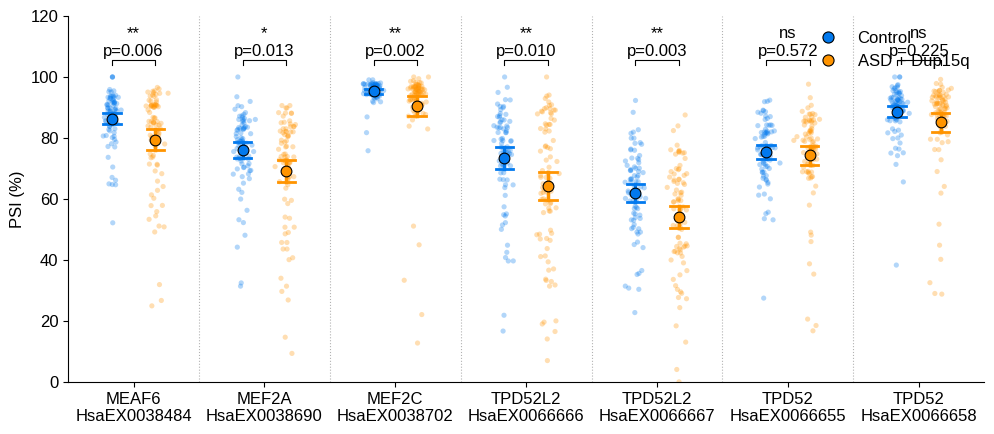


Saved to ../outputs/ASD_PSI.png and .svg

Summary:
                Event  n_Ctrl  n_Case  mean_Ctrl  mean_Case  median_Ctrl  median_Case  delta_mean  ratio_mean  pct_change  ratio_IQR_lo  ratio_IQR_hi  MW_p
  MEAF6\nHsaEX0038484      82      87     86.347     79.483       88.615       84.240       6.864       0.921      -4.937         0.831         1.023 0.006
  MEF2A\nHsaEX0038690      82      87     76.018     69.150       78.645       72.800       6.868       0.910      -7.432         0.815         1.043 0.013
  MEF2C\nHsaEX0038702      82      87     95.277     90.501       95.690       94.690       4.775       0.950      -1.045         0.954         1.008 0.002
TPD52L2\nHsaEX0066666      82      87     73.445     64.188       75.995       66.750       9.258       0.874     -12.165         0.639         1.110 0.010
TPD52L2\nHsaEX0066667      82      87     61.919     54.101       63.115       56.540       7.818       0.874     -10.417         0.689         1.059 0.003
  TPD52\nHsa

In [15]:
# Spacing: smaller = tighter pairs and tighter events
PAIR_GAP = 0.5      # distance between Control and ASD within an event
EVENT_GAP = 1.5     # distance between events (center-to-center)

# --- 1. Discover and load splicing CSV files ---
all_csv = sorted(glob.glob(f'{DATA_DIR}/*.csv'))
csv_files = []
for f in all_csv:
    header = pd.read_csv(f, nrows=0).columns
    if REQUIRED_COLS.issubset(set(header)):
        csv_files.append(f)

print(f'Found {len(csv_files)} splicing CSV files (out of {len(all_csv)} total CSVs)')

all_data = []
for f in csv_files:
    df = pd.read_csv(f)
    gene = df['GENE'].iloc[0]
    event_id = df['EVENT'].iloc[0]
    length = df['LENGTH'].iloc[0]
    df['event_label'] = f'{gene}\n{event_id}'   # gene symbol + event ID
    all_data.append(df)
    print(f'  {gene} ({event_id}, {length}nt): {len(df)} rows')

combined = pd.concat(all_data, ignore_index=True)

# --- 2. Combine ASD + Dup15q ---
combined['group_combined'] = combined['group'].map(
    lambda x: 'Control' if x == 'Control' else 'ASD + Dup15q'
)

# --- 3. Get unique events in file order ---
events = combined['event_label'].unique()
n_events = len(events)

# --- 4. Create figure ---
fig_w = max(n_events * EVENT_GAP * 0.85 + 1.2, 3.5)
fig, ax = plt.subplots(figsize=(fig_w, 4.5))

rng = np.random.default_rng(42)

for i, event in enumerate(events):
    sub = combined[combined['event_label'] == event]
    ctrl = sub[sub['group_combined'] == 'Control']['PSI'].values
    case = sub[sub['group_combined'] == 'ASD + Dup15q']['PSI'].values
    x_ctrl = i * EVENT_GAP
    x_case = i * EVENT_GAP + PAIR_GAP

    for x_pos, vals, color in [(x_ctrl, ctrl, COLOR_CTRL), (x_case, case, COLOR_CASE)]:
        if len(vals) == 0:
            continue
        mean = np.mean(vals)
        sem = np.std(vals, ddof=1) / np.sqrt(len(vals))
        ci95 = sem * 1.96
        jitter = rng.normal(0, 0.05, size=len(vals))
        ax.scatter(x_pos + jitter, vals, color=color, alpha=0.3, s=14,
                   edgecolors='none', zorder=1)
        ax.scatter(x_pos, mean, color=color, s=60, zorder=3,
                   edgecolors='black', linewidths=0.8)
        ax.plot([x_pos, x_pos], [mean - ci95, mean + ci95],
                color=color, linewidth=2.5, zorder=2)
        ax.plot([x_pos - 0.1, x_pos + 0.1], [mean - ci95, mean - ci95],
                color=color, linewidth=2, zorder=2)
        ax.plot([x_pos - 0.1, x_pos + 0.1], [mean + ci95, mean + ci95],
                color=color, linewidth=2, zorder=2)

    # Mann-Whitney p-value bracket
    if len(ctrl) > 0 and len(case) > 0:
        _, p = mannwhitneyu(case, ctrl, alternative='two-sided')
        y_max = max(sub['PSI'].max(), 100)
        y_bracket = y_max + 4
        ax.plot([x_ctrl, x_ctrl, x_case, x_case],
                [y_bracket, y_bracket + 1.5, y_bracket + 1.5, y_bracket],
                'k-', lw=0.8)
        if p < 0.001:
            label = f'***\np={p:.1e}'
        elif p < 0.01:
            label = f'**\np={p:.3f}'
        elif p < 0.05:
            label = f'*\np={p:.3f}'
        else:
            label = f'ns\np={p:.3f}'
        ax.text((x_ctrl + x_case) / 2, y_bracket + 2, label,
                ha='center', va='bottom', fontsize=FONT_SIZE)

# --- 4b. Dotted separation lines between events ---
for i in range(1, n_events):
    x_sep = i * EVENT_GAP - (EVENT_GAP - PAIR_GAP) / 2
    ax.axvline(x_sep, color='gray', linestyle=':', linewidth=0.8,
               zorder=0, alpha=0.6)

# --- 5. Formatting ---
ax.set_xticks([i * EVENT_GAP + PAIR_GAP / 2 for i in range(n_events)])
ax.set_xticklabels(events)
ax.set_ylabel('PSI (%)')
ax.set_ylim(0, 120)
ax.set_xlim(-0.5, (n_events - 1) * EVENT_GAP + PAIR_GAP + 0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [
    Line2D([0], [0], marker='o', color=COLOR_CTRL, markersize=8,
           markeredgecolor='black', markeredgewidth=0.8, linestyle='None',
           label='Control'),
    Line2D([0], [0], marker='o', color=COLOR_CASE, markersize=8,
           markeredgecolor='black', markeredgewidth=0.8, linestyle='None',
           label='ASD + Dup15q'),
]
ax.legend(handles=legend_elements, frameon=False,
          loc='upper right', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
fig.savefig(f'{OUTPUT_PREFIX}.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUTPUT_PREFIX}.svg', bbox_inches='tight')
plt.show()
print(f'\nSaved to {OUTPUT_PREFIX}.png and .svg')

# --- 6. Summary table (stats + median ratio) ---
summary = []
for event in events:
    sub = combined[combined['event_label'] == event]
    ctrl = sub[sub['group_combined'] == 'Control']['PSI'].values
    case = sub[sub['group_combined'] == 'ASD + Dup15q']['PSI'].values
    _, p = mannwhitneyu(case, ctrl, alternative='two-sided')

    med_ctrl = np.median(ctrl)
    med_case = np.median(case)
    mean_ctrl = np.mean(ctrl)
    mean_case = np.mean(case)
    
    ratio_medians = med_case / med_ctrl
    ratio_mean = (mean_ctrl - mean_case)/mean_ctrl

    pct_change = (ratio_medians - 1) * 100
    ratios_case = case / med_ctrl
    ratio_iqr_lo = np.percentile(ratios_case, 25)
    ratio_iqr_hi = np.percentile(ratios_case, 75)

    summary.append({
        'Event': event,
        'n_Ctrl': len(ctrl), 'n_Case': len(case),
        'mean_Ctrl': np.mean(ctrl), 'mean_Case': np.mean(case),
        'median_Ctrl': med_ctrl, 'median_Case': med_case,
        'delta_mean': np.mean(ctrl) - np.mean(case),
        'ratio_mean': ratio_mean,
        'pct_change': pct_change,
        'ratio_IQR_lo': ratio_iqr_lo, 'ratio_IQR_hi': ratio_iqr_hi,
        'MW_p': p,
    })
summary_df = pd.DataFrame(summary)
print('\nSummary:')
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.3f}' if abs(x) < 100 else f'{x:.0f}'))

# Save summary to CSV
csv_out = f'{OUTPUT_PREFIX}_summary.csv'
summary_df.to_csv(csv_out, index=False)
print(f'\nSaved summary to {csv_out}')
